#  Task 8: Resume Screening Using NLP

**Goal:** Automatically screen and rank resumes against job descriptions using semantic similarity  
**Datasets:**
- Resumes  -> `InferencePrince555/Resume-Dataset` (Hugging Face) — 32k resumes across 52 job roles
- Jobs     ->> `jacob-hugging-face/job-descriptions` (Hugging Face) — real job postings

**Topics:** Document Similarity | Semantic Search | Sentence Embeddings | Cosine Similarity  

---
### How It Works
```
Resume Text ──┐
              \--> Sentence Transformer (Embeddings) --> Cosine Similarity --> Ranked Results
Job Desc   ──┘
```
Instead of keyword matching, we use **semantic embeddings** — the model understands *meaning*,  
so "Python developer(DS, ML, AI)" and "software engineer with Python experience" are treated as similar.

---
## Step 1: Install & Import Libraries

In [1]:
# Install all required packages
# sentence-transformers : creates semantic embeddings from text
# datasets              : loads data from Hugging Face
# scikit-learn          : cosine similarity calculation
# spacy                 : named entity extraction (bonus)
!pip install sentence-transformers datasets scikit-learn pandas numpy matplotlib seaborn spacy --quiet
!python -m spacy download en_core_web_sm --quiet

[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

# Core NLP tools
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import spacy

plt.style.use('seaborn-v0_8-whitegrid')
print(' All libraries imported!')

 All libraries imported!


---
## Step 2: Load Datasets

We load two datasets:
- **Resume dataset** -> 32,500 resumes labelled by job category
- **Job descriptions dataset** -> real job postings with titles and full descriptions

In [3]:
# ── Load Resumes ──────────────────────────────────────────────────────────────
# This dataset has 32k resumes. 
print('Loading resume dataset...')
resume_raw = load_dataset('InferencePrince555/Resume-Dataset', split='train')
resume_df  = pd.DataFrame(resume_raw)

# Clean up the column names and extract just the job category
# e.g. "Generate a Resume for a Data Scientist Job" -> "Data Scientist"
resume_df = resume_df.rename(columns={'Resume_test': 'resume_text', 'instruction': 'raw_category'})
resume_df['category'] = resume_df['raw_category'].str.extract(r'for a (.+?) Job', expand=False)
resume_df = resume_df[['category', 'resume_text']].dropna()

print(f' Resumes loaded    : {len(resume_df):,}')
print(f'   Job categories   : {resume_df["category"].nunique()}')
print(f'   Sample categories: {resume_df["category"].unique()[:5].tolist()}')

Loading resume dataset...


README.md:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

updated_data_final_cleaned.csv:   0%|          | 0.00/206M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/32481 [00:00<?, ? examples/s]

 Resumes loaded    : 32,480
   Job categories   : 52
   Sample categories: ['Accountant', 'Advocate', 'Agriculture', 'Apparel', 'Arts']


In [4]:
# ── Load Job Descriptions 
# This dataset has real job postings scraped from the web.
# Each row has a job title and a full job description.
print('Loading job descriptions dataset...')
jobs_raw = load_dataset('jacob-hugging-face/job-descriptions', split='train')
jobs_df  = pd.DataFrame(jobs_raw)

print(f' Job postings loaded: {len(jobs_df):,}')
print(f'   Columns           : {list(jobs_df.columns)}')


Loading job descriptions dataset...


README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

training_data.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/853 [00:00<?, ? examples/s]

 Job postings loaded: 853
   Columns           : ['company_name', 'job_description', 'position_title', 'description_length', 'model_response']


In [6]:

jobs_df.head(5)

,company_name,job_description,position_title,description_length,model_response
0,Google,minimum qualifications\nbachelors degree or eq...,Sales Specialist,2727,"{\n ""Core Responsibilities"": ""Responsible fo..."
1,Apple,description\nas an asc you will be highly infl...,Apple Solutions Consultant,828,"{\n ""Core Responsibilities"": ""as an asc you ..."
2,Netflix,its an amazing time to be joining netflix as w...,Licensing Coordinator - Consumer Products,3205,"{\n ""Core Responsibilities"": ""Help drive bus..."
3,Robert Half,description\n\nweb designers looking to expand...,Web Designer,2489,"{\n ""Core Responsibilities"": ""Designing webs..."
4,TrackFive,at trackfive weve got big goals were on a miss...,Web Developer,3167,"{\n ""Core Responsibilities"": ""Build and layo..."


In [7]:
# Keep only the most useful columns and drop rows with missing descriptions
jobs_df = jobs_df[['position_title', 'job_description']].dropna()
jobs_df = jobs_df.rename(columns={'position_title': 'job_title', 'job_description': 'job_text'})

print(f'Job postings (after cleaning): {len(jobs_df):,}')
print(f'\nSample job titles:')
print(jobs_df['job_title'].head(8).tolist())

Job postings (after cleaning): 853

Sample job titles:
['Sales Specialist', 'Apple Solutions Consultant', 'Licensing Coordinator - Consumer Products', 'Web Designer', 'Web Developer', 'Frontend Web Developer', 'Remote Website Designer', 'Web Designer']


---
## Step 3: Exploratory Data Analysis

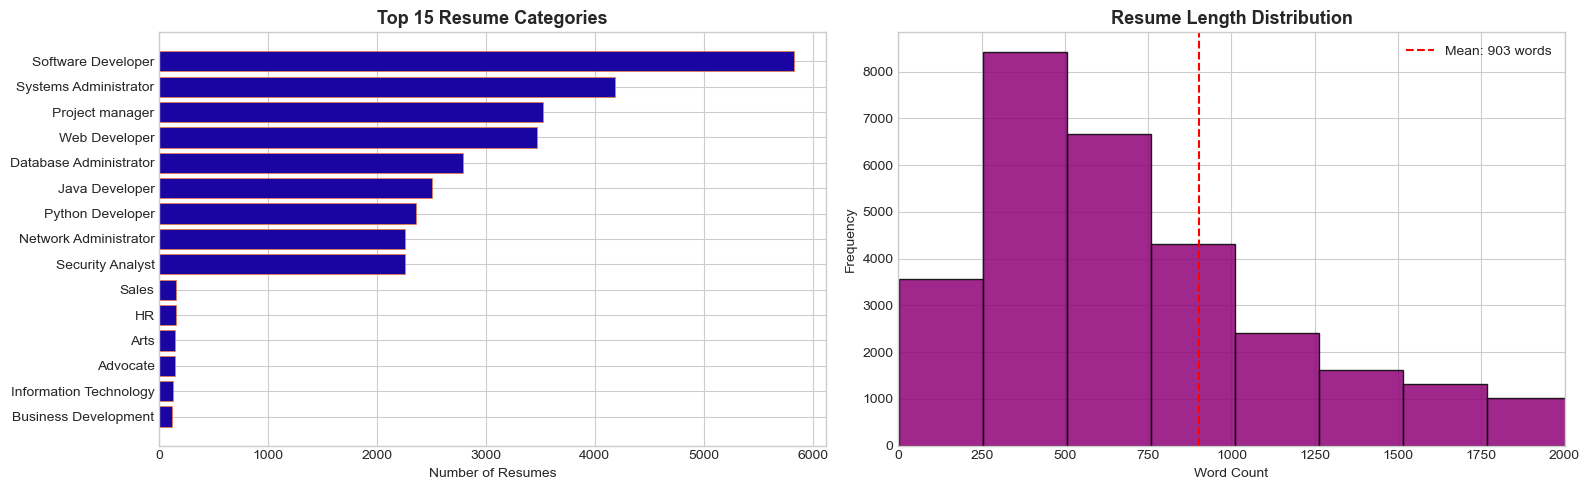

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Top 15 Resume Categories 
top_cats = resume_df['category'].value_counts().head(15)
axes[0].barh(list(reversed(top_cats.index)), list(reversed(top_cats.values)),
             color='#1A05A2', edgecolor='#F67D31', linewidth=0.5)
axes[0].set_title('Top 15 Resume Categories', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Resumes')

# ── Resume Text Length Distribution
# Helps us understand how long the resumes are (important for truncating them)
resume_df['word_count'] = resume_df['resume_text'].apply(lambda x: len(str(x).split()))
axes[1].hist(resume_df['word_count'], bins=50, color='#8F0177', edgecolor='black', alpha=0.85)
axes[1].axvline(resume_df['word_count'].mean(), color='red', linestyle='--',
                label=f'Mean: {resume_df["word_count"].mean():.0f} words')
axes[1].set_title('Resume Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 2000)
axes[1].legend()

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 4: Text Preprocessing

We clean the text before embedding:
- Remove extra whitespace and special characters
- Truncate very long resumes (sentence transformers have a 512 token limit)

In [9]:
def clean_text(text, max_words=300):
    """
    Clean and truncate text.

     max_words=300
    Sentence transformer models have a token limit (~512 tokens ≈ 350-400 words).
    We truncate to 300 words to be safe and keep the most important content
    (typically found at the beginning of a resume or job description).
    """
    text = str(text)
    text = re.sub(r'\s+', ' ', text)          
    # collapse multiple spaces/newlines
    text = re.sub(r'[^\w\s.,;:()/\-]', '', text)  
    # remove special chars but keep punctuation
    text = text.strip()
    # Truncate to max_words
    words = text.split()
    return ' '.join(words[:max_words])


# Apply cleaning to both datasets
resume_df['resume_clean'] = resume_df['resume_text'].apply(clean_text)
jobs_df['job_clean']      = jobs_df['job_text'].apply(lambda x: clean_text(x, max_words=200))

print(' Text cleaning done!')
print(f'\nResume example (first 200 chars after cleaning):')
print(resume_df['resume_clean'].iloc[0][:200])
print(f'\nJob description example (first 200 chars):')
print(jobs_df['job_clean'].iloc[0][:200])

 Text cleaning done!

Resume example (first 200 chars after cleaning):
ACCOUNTANT Professional Summary Results oriented and organized bilingual accounting and finance professional with 10 years extensive and diverse accounting auditing and finance experience Experience i

Job description example (first 200 chars):
minimum qualifications bachelors degree or equivalent practical experience years of experience in saas or productivity tools businessexperience managing enterprise accounts with sales cycles preferred


---
## Step 5: Load Sentence Transformer Model

**What is a Sentence Transformer?**  
It converts any text into a fixed-size vector (embedding) that captures semantic meaning.  
Two texts with similar meanings will have embeddings that are close together in vector space.

We use `all-MiniLM-L6-v2` — a lightweight but highly accurate model optimised for semantic similarity.

In [10]:
# 'all-MiniLM-L6-v2' is one of the best small models for semantic similarity.
# It produces 384-dimensional embeddings and is very fast.
print('Loading sentence transformer model...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print(f'✅ Model loaded!')
print(f'   Embedding dimensions: {embedder.get_sentence_embedding_dimension()}')

Loading sentence transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded!
   Embedding dimensions: 384


---
## Step 6: Build the Resume Screening System

The core function:
1. Takes a **job description** as input
2. Encodes it into an embedding vector
3. Compares it to all resume embeddings using **cosine similarity**
4. Returns the **top-N ranked resumes** with match scores and justifications

In [11]:
# ── Prepare a balanced sample of resumes for evaluation ───────────────────────
# We take 40 resumes per category to keep it balanced and manageable.

RESUMES_PER_CATEGORY = 40

sample_df = (
    resume_df
    .groupby('category', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), RESUMES_PER_CATEGORY), random_state=42))
    .reset_index(drop=True)
)

print(f'Sample size : {len(sample_df):,} resumes across {sample_df["category"].nunique()} categories')

# ── Encode all resumes into embeddings 
# This is done ONCE and reused for every job description.
# Each resume becomes a 384-dimensional vector.
print('\nEncoding resumes into embeddings (this may take ~1-2 minutes)...')
resume_embeddings = embedder.encode(
    sample_df['resume_clean'].tolist(),
    batch_size=64,
    show_progress_bar=True
)

print(f'\n Resume embeddings shape: {resume_embeddings.shape}')
print(f'   Each resume → vector of {resume_embeddings.shape[1]} numbers')

Sample size : 1,936 resumes across 52 categories

Encoding resumes into embeddings (this may take ~1-2 minutes)...


Batches:   0%|          | 0/31 [00:00<?, ?it/s]


 Resume embeddings shape: (1936, 384)
   Each resume → vector of 384 numbers


In [12]:
def screen_resumes(job_description, top_n=10):
    """
    Rank resumes against a job description using cosine similarity.

    How it works:
    1. The job description is encoded into a single embedding vector.
    2. We compute cosine similarity between the job vector and every resume vector.
       - Cosine similarity = 1.0 means identical direction (perfect match)
       - Cosine similarity = 0.0 means completely unrelated
    3. Resumes are ranked from highest to lowest similarity score.

    Args:
        job_description : str   — the full job posting text
        top_n           : int   — how many top resumes to return

    Returns:
        DataFrame with ranked resumes, scores, and justifications
    """
    # Step 1: Clean and encode the job description
    job_clean     = clean_text(job_description, max_words=200)
    job_embedding = embedder.encode([job_clean])   # shape: (1, 384)

    # Step 2: Compute cosine similarity between job and ALL resumes
    # Result shape: (1, num_resumes) — one score per resume
    similarities = cosine_similarity(job_embedding, resume_embeddings)[0]

    # Step 3: Get top-N resume indices sorted by similarity (highest first)
    top_indices = np.argsort(similarities)[::-1][:top_n]

    # Step 4: Build results DataFrame
    results = []
    for rank, idx in enumerate(top_indices, start=1):
        score    = similarities[idx]
        category = sample_df['category'].iloc[idx]
        snippet  = sample_df['resume_clean'].iloc[idx][:150] + '...'

        # Generate a simple justification label based on score
        if score >= 0.7:
            match_label = '🟢 Strong Match'
        elif score >= 0.5:
            match_label = '🟡 Good Match'
        elif score >= 0.35:
            match_label = '🟠 Partial Match'
        else:
            match_label = '🔴 Weak Match'

        results.append({
            'Rank'        : rank,
            'Match'       : match_label,
            'Score'       : round(float(score), 4),
            'Category'    : category,
            'Resume Snippet': snippet
        })

    return pd.DataFrame(results)


print(' Screening function ready!')

 Screening function ready!


---
## Step 7: Screen Resumes ->> Live Demo for testing teh function 

We run the system against real job descriptions from our dataset.

In [14]:
# ── Pick a real job description from the dataset 
sample_job = jobs_df.iloc[0]

print(f' JOB TITLE  : {sample_job["job_title"]}')
print(f' DESCRIPTION: {sample_job["job_clean"][:300]}...')
print()

# Run the screening system
results = screen_resumes(sample_job['job_clean'], top_n=10)

print(' TOP 10 RANKED RESUMES ')
pd.set_option('display.max_colwidth', 80)
results[['Rank', 'Match', 'Score', 'Category', 'Resume Snippet']]

 JOB TITLE  : Sales Specialist
 DESCRIPTION: minimum qualifications bachelors degree or equivalent practical experience years of experience in saas or productivity tools businessexperience managing enterprise accounts with sales cycles preferred qualifications years of experience building strategic business partnerships with enterprise custome...

 TOP 10 RANKED RESUMES 


,Rank,Match,Score,Category,Resume Snippet
0,1,🟡 Good Match,0.5562,Python Developer,Software Developer Technician 2 span lSoftwarespan span lDeveloperspan Techn...
1,2,🟡 Good Match,0.5559,Systems Administrator,Sr IT ProjectProgram Manager Consultant Sr span lITspan span lProjectspanPro...
2,3,🟡 Good Match,0.5546,Consultant,CONSULTANT Professional Summary High achieving management professional and e...
3,4,🟡 Good Match,0.5528,Java Developer,Systems Administrator span lSystemsspan span lAdministratorspan Systems Admi...
4,5,🟡 Good Match,0.5456,Network Administrator,IT Project Manager Consultant Owner span lITspan span lProjectspan span lMan...
5,6,🟡 Good Match,0.5448,BPO,BUSINESS ACCOUNT LEAD Executive Profile Strong Service Delivery Operations M...
6,7,🟡 Good Match,0.5424,Network Administrator,Business System Analyst Python Developer Business System Analystspan lPython...
7,8,🟡 Good Match,0.5422,PMO,AREA OF EXPERTISE PROFILE Around 10 plus years proven experience with best g...
8,9,🟡 Good Match,0.5422,PMO,AREA OF EXPERTISE PROFILE Around 10 plus years proven experience with best g...
9,10,🟡 Good Match,0.5422,PMO,AREA OF EXPERTISE PROFILE Around 10 plus years proven experience with best g...


In [15]:
# ── Test on a second job description
sample_job_2 = jobs_df.iloc[5]

print(f' JOB TITLE  : {sample_job_2["job_title"]}')
print(f' DESCRIPTION: {sample_job_2["job_clean"][:300]}...')
print()

results_2 = screen_resumes(sample_job_2['job_clean'], top_n=10)
print(' TOP 10 RANKED RESUMES ')
results_2[['Rank', 'Match', 'Score', 'Category', 'Resume Snippet']]

 JOB TITLE  : Frontend Web Developer
 DESCRIPTION: designups is a nashville based design and interactive agency at designups we have a strong focus on elevating brands with our expertise in design and customer experience are you a frontend developer with a serious interest in design and ui this could be a great fit if so this job is for someone in t...

 TOP 10 RANKED RESUMES 


,Rank,Match,Score,Category,Resume Snippet
0,1,🟡 Good Match,0.6266,Java Developer,Lead UIUX Designer Lead UIUX Designer Accomplished designer and web develope...
1,2,🟡 Good Match,0.6095,Database Administrator,Front End Developer span lFrontspan span lEndspan span lDeveloperspan front ...
2,3,🟡 Good Match,0.5981,Python Developer,Freelance Front End Developer Freelance span lFrontspan span lEndspan span l...
3,4,🟡 Good Match,0.5865,Designer,FREELANCE WEBSITE DESIGNER Summary Marine Corps trained leader and business ...
4,5,🟡 Good Match,0.5810,Designer,GRAPHIC DESIGNER Summary A graphic designer who is creative and detail orien...
5,6,🟡 Good Match,0.5754,Designer,Zachory Edmiston Summary Skilled in Customer Service Motivated to enhance cu...
6,7,🟡 Good Match,0.5731,Web Developer,freelance web developer freelance span lwebspan span ldeveloperspan Frontend...
7,8,🟡 Good Match,0.5721,Project manager,UI Designer and Developer UI Designer and span lDeveloperspan UI Designer an...
8,9,🟡 Good Match,0.5670,Security Analyst,Principal Consultant Principal Consultant Houston TX My objective is to obta...
9,10,🟡 Good Match,0.5624,Security Analyst,Web Designer Developer span lWebspan Designerspan lDeveloperspan West Bend W...


---
## Step 8: Visualize Match Scores

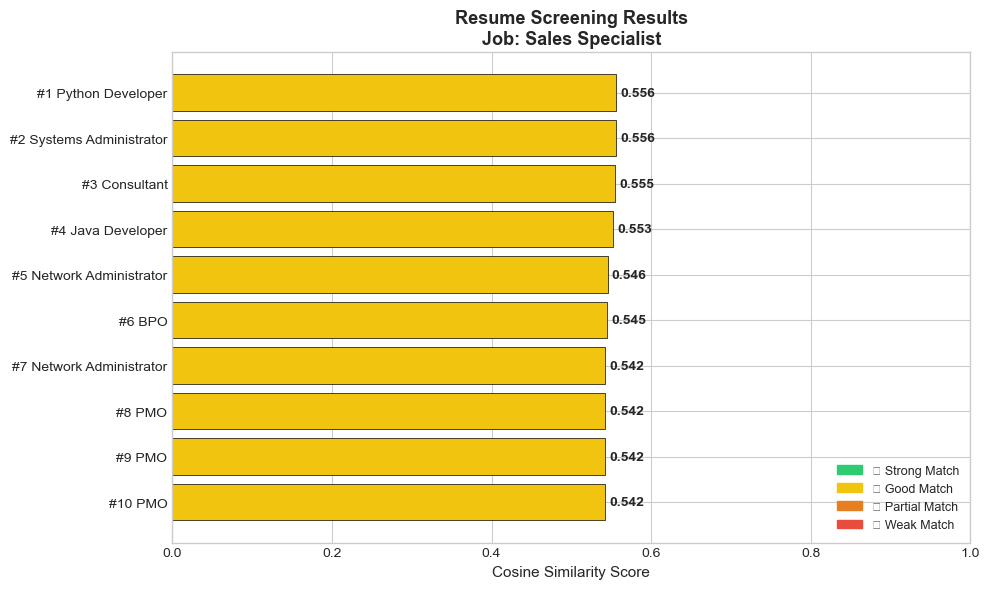

In [16]:
def plot_scores(results, job_title):
    """
    Horizontal bar chart of top resume scores.
    Color-coded by match strength.
    """
    # Color map: strong = green, good = yellow, partial = orange, weak = red
    color_map = {
        '🟢 Strong Match' : '#2ecc71',
        '🟡 Good Match'   : '#f1c40f',
        '🟠 Partial Match': '#e67e22',
        '🔴 Weak Match'   : '#e74c3c'
    }
    colors = [color_map.get(m, '#95a5a6') for m in results['Match']]
    labels = [f"#{r} {cat}" for r, cat in zip(results['Rank'], results['Category'])]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(list(reversed(labels)), list(reversed(results['Score'])),
                   color=list(reversed(colors)), edgecolor='black', linewidth=0.5)

    # Add score labels
    for bar, score in zip(bars, reversed(results['Score'].tolist())):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', va='center', fontsize=10, fontweight='bold')

    ax.set_title(f'Resume Screening Results\nJob: {job_title}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Cosine Similarity Score', fontsize=11)
    ax.set_xlim(0, 1.0)

    # Legend
    legend_patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
    ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.savefig('screening_results.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_scores(results, sample_job['job_title'])

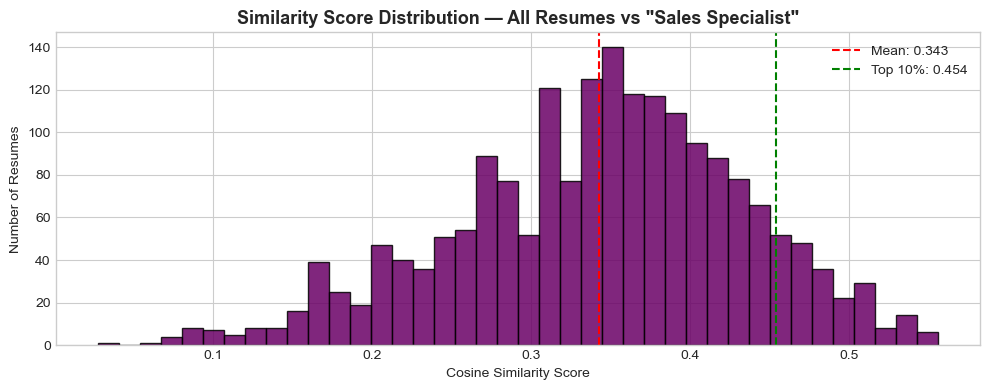

Mean similarity  : 0.3428
Max similarity   : 0.5562
Top 10% threshold: 0.4545


In [17]:
# ── Score distribution across all resumes for a given job 
# This shows how discriminative the model is, are most resumes weak matches
# or are scores clustered together?

job_clean     = clean_text(sample_job['job_clean'])
job_embedding = embedder.encode([job_clean])
all_scores    = cosine_similarity(job_embedding, resume_embeddings)[0]

plt.figure(figsize=(10, 4))
plt.hist(all_scores, bins=40, color='#6A0066', edgecolor='black', alpha=0.85)
plt.axvline(all_scores.mean(), color='red', linestyle='--',
            label=f'Mean: {all_scores.mean():.3f}')
plt.axvline(np.percentile(all_scores, 90), color='green', linestyle='--',
            label=f'Top 10%: {np.percentile(all_scores, 90):.3f}')
plt.title(f'Similarity Score Distribution — All Resumes vs "{sample_job["job_title"]}"',
          fontsize=13, fontweight='bold')
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Number of Resumes')
plt.legend()
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean similarity  : {all_scores.mean():.4f}')
print(f'Max similarity   : {all_scores.max():.4f}')
print(f'Top 10% threshold: {np.percentile(all_scores, 90):.4f}')

---
## Step 9: Screen Multiple Jobs at Once — Batch Mode

In [18]:
# Run screening for the first 5 jobs and collect the top-3 match category per job
# This shows how the system works at scale

print(' Batch Screening: Top 3 Matches Per Job \n')

batch_rows = []
for _, job_row in jobs_df.head(5).iterrows():
    top3 = screen_resumes(job_row['job_clean'], top_n=3)
    for _, r in top3.iterrows():
        batch_rows.append({
            'Job Title'    : job_row['job_title'][:50],
            'Rank'         : r['Rank'],
            'Resume Cat.'  : r['Category'],
            'Score'        : r['Score'],
            'Match'        : r['Match']
        })

batch_df = pd.DataFrame(batch_rows)
batch_df

 Batch Screening: Top 3 Matches Per Job 



,Job Title,Rank,Resume Cat.,Score,Match
0,Sales Specialist,1,Python Developer,0.5562,🟡 Good Match
1,Sales Specialist,2,Systems Administrator,0.5559,🟡 Good Match
2,Sales Specialist,3,Consultant,0.5546,🟡 Good Match
3,Apple Solutions Consultant,1,Apparel,0.4913,🟠 Partial Match
4,Apple Solutions Consultant,2,Public Relations,0.4841,🟠 Partial Match
5,Apple Solutions Consultant,3,Sales,0.4836,🟠 Partial Match
6,Licensing Coordinator - Consumer Products,1,Digital Media,0.4702,🟠 Partial Match
7,Licensing Coordinator - Consumer Products,2,Consultant,0.4652,🟠 Partial Match
8,Licensing Coordinator - Consumer Products,3,Network Administrator,0.4646,🟠 Partial Match
9,Web Designer,1,Systems Administrator,0.6869,🟡 Good Match


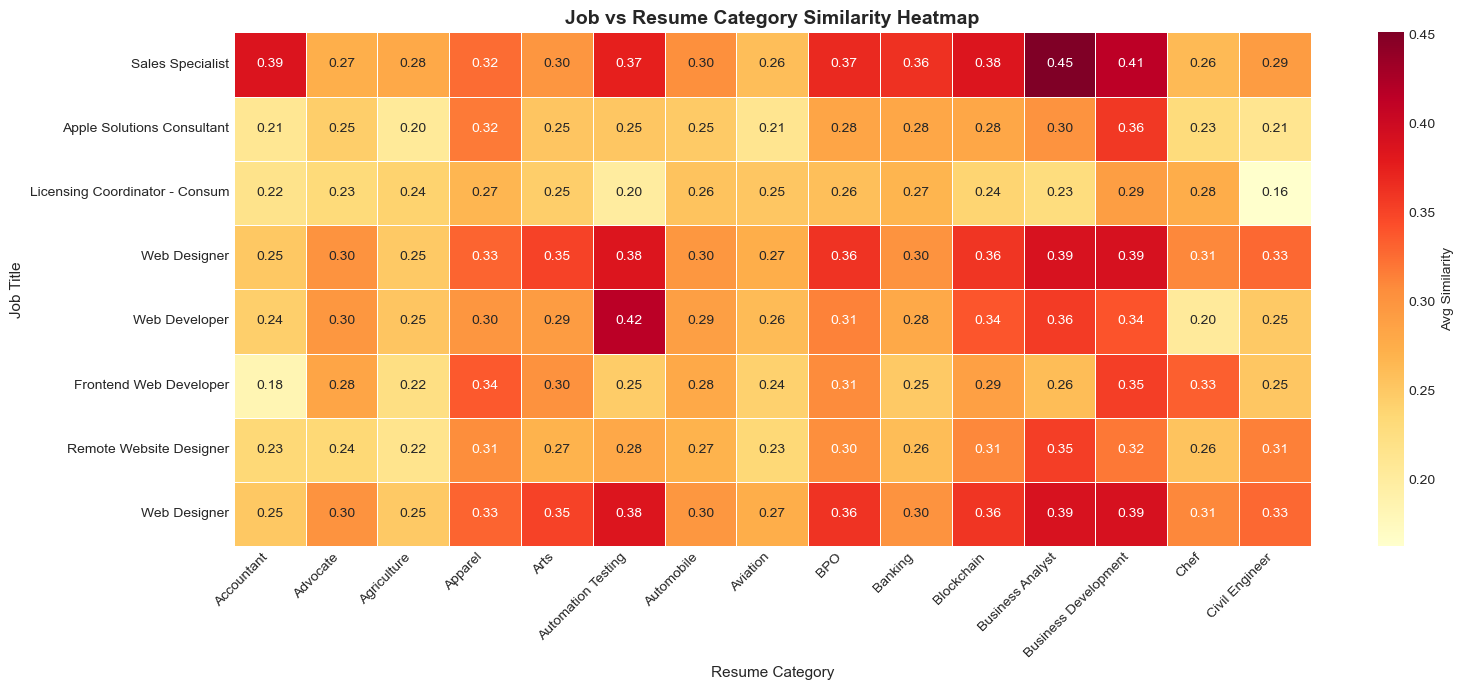

In [19]:
# Heatmap: job titles vs top resume categories
# Shows which resume category scores highest for each job

# Build a score matrix (jobs × categories)
all_job_titles  = jobs_df['job_title'].head(8).tolist()
all_categories  = sample_df['category'].unique()[:15].tolist()

score_matrix = np.zeros((len(all_job_titles), len(all_categories)))

for i, job_title in enumerate(all_job_titles):
    jd    = jobs_df[jobs_df['job_title'] == job_title]['job_clean'].iloc[0]
    jd_emb = embedder.encode([clean_text(jd)])
    sims   = cosine_similarity(jd_emb, resume_embeddings)[0]

    # Average similarity score per category
    for j, cat in enumerate(all_categories):
        cat_mask = sample_df['category'] == cat
        if cat_mask.sum() > 0:
            score_matrix[i, j] = sims[cat_mask].mean()

heatmap_df = pd.DataFrame(score_matrix,
                           index=[t[:30] for t in all_job_titles],
                           columns=all_categories)

plt.figure(figsize=(16, 7))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Avg Similarity'})
plt.title('Job vs Resume Category Similarity Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Resume Category', fontsize=11)
plt.ylabel('Job Title', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 10 : Named Entity Extraction from Resumes

We use spaCy to extract **skills, organizations, and titles** mentioned in the top resumes —  
this gives a richer justification beyond just a similarity score.

In [20]:
# Load spaCy model for named entity recognition
nlp = spacy.load('en_core_web_sm')

# Common tech skills to look for in resume text
SKILL_KEYWORDS = [
    'python', 'sql', 'java', 'javascript', 'machine learning', 'deep learning',
    'tensorflow', 'pytorch', 'pandas', 'numpy', 'excel', 'tableau', 'power bi',
    'aws', 'azure', 'docker', 'kubernetes', 'git', 'react', 'node', 'django',
    'nlp', 'data analysis', 'statistics', 'R programming', 'spark', 'hadoop',
    'Go'
]


def extract_resume_info(resume_text):
    """
    Extract key information from a resume:
    - Organizations (companies, universities) via spaCy NER
    - Skills via keyword matching against a skills list

    Returns a dict with 'organizations' and 'skills' found.
    """
    doc = nlp(resume_text[:1500])  # limit for speed

    # spaCy NER: grab organisations and locations
    orgs = list(set([
        ent.text.strip() for ent in doc.ents
        if ent.label_ in ('ORG', 'GPE') and len(ent.text.strip()) > 2
    ]))[:5]

    # Keyword-based skill extraction
    text_lower = resume_text.lower()
    found_skills = [skill for skill in SKILL_KEYWORDS if skill in text_lower]

    return {'organizations': orgs, 'skills': found_skills}


# Apply to top 5 results from earlier
print(f' Enriched Resume Analysis — Job: {sample_job["job_title"]} \n')

top5 = screen_resumes(sample_job['job_clean'], top_n=5)

for _, row in top5.iterrows():
    # Get the actual resume text for this result
    # We match by category to find a representative resume
    resume_text = sample_df[sample_df['category'] == row['Category']]['resume_clean'].iloc[0]
    info = extract_resume_info(resume_text)

    print(f"Rank #{row['Rank']} — {row['Match']} — Score: {row['Score']}")
    print(f"  Category     : {row['Category']}")
    print(f"  Skills found : {', '.join(info['skills'][:8]) if info['skills'] else 'None detected'}")
    print(f"  Orgs/Places  : {', '.join(info['organizations'][:4]) if info['organizations'] else 'None detected'}")
    print()

 Enriched Resume Analysis — Job: Sales Specialist 

Rank #1 — 🟡 Good Match — Score: 0.5562
  Category     : Python Developer
  Skills found : sql, excel
  Orgs/Places  : Market Data Retrieval Shelton CT, Utilize, Analyzed, Education BA

Rank #2 — 🟡 Good Match — Score: 0.5559
  Category     : Systems Administrator
  Skills found : git
  Orgs/Places  : Lead Incident Response, Local Agency Security, Network Administrator CJIS Local Agency, Network Administrator City of

Rank #3 — 🟡 Good Match — Score: 0.5546
  Category     : Consultant
  Skills found : excel
  Orgs/Places  : MJFreeway, MIP Manufacturing CO State, Dispensary Retail OPC Grow, Operations

Rank #4 — 🟡 Good Match — Score: 0.5528
  Category     : Java Developer
  Skills found : python, java, javascript, git
  Orgs/Places  : Stony Brook University, New York, Scratch, httpswwwlinkedincominmarisadepasquale23709784 httpsgithubcomMarisaDe

Rank #5 — 🟡 Good Match — Score: 0.5456
  Category     : Network Administrator
  Skills found :

---
## Step 11 : Upload Your Own Resume

Paste any resume text and any job description to get an instant match score.

In [21]:
def match_single_resume(resume_text, job_description):
    """
    Check how well a single resume matches a single job description.

    Returns the similarity score and a match label.
    Perfect for testing !
    """
    # Encode both texts into embedding vectors
    resume_emb = embedder.encode([clean_text(resume_text)])
    job_emb    = embedder.encode([clean_text(job_description)])

    # Calculate cosine similarity
    score = float(cosine_similarity(resume_emb, job_emb)[0][0])

    # Determine label
    if score >= 0.7:
        label = '🟢 Strong Match -> You are a great fit!'
    elif score >= 0.5:
        label = '🟡 Good Match —> Worth applying!'
    elif score >= 0.35:
        label = '🟠 Partial Match —> Some alignment, consider tailoring your resume.'
    else:
        label = '🔴 Weak Match —> Your background may not fit this role. Try! andother job'

    # Also extract skills from resume
    info = extract_resume_info(resume_text)

    print(f'Match Score  : {score:.4f}  ({score*100:.1f}%)')
    print(f'Result       : {label}')
    print(f'Skills found : {", ".join(info["skills"][:10]) if info["skills"] else "None detected"}')
    return score


# ── Example: we  paste our  resume here and job description below
my_resume = """
Data Scientist with 3 years of experience in machine learning and NLP.
Proficient in Python, pandas, numpy, scikit-learn, TensorFlow, and PyTorch.
Worked on text classification, named entity recognition, and recommendation systems.
Experience with SQL, AWS, and building data pipelines using Spark.
Btech in Computer Science (Software Engineering) from University of Cameroon.
"""

my_job = """
We are looking for a Machine Learning Engineer to join our AI team.
You will build NLP models for text classification and information extraction.
Requirements: Python, TensorFlow or PyTorch, experience with transformers and BERT.
Experience with cloud platforms (AWS or GCP) is a plus.
Strong understanding of machine learning fundamentals required.
"""

print('Single Resume Match ')
match_single_resume(my_resume, my_job)

Single Resume Match 
Match Score  : 0.6399  (64.0%)
Result       : 🟡 Good Match —> Worth applying!
Skills found : python, sql, machine learning, tensorflow, pytorch, pandas, numpy, aws, nlp, spark


0.639867901802063

---
## Step 12: Final Summary

In [23]:
print('=' * 60)
print('       RESUME SCREENING USING NLP —>>>> SUMMARY')
print('=' * 60)
print(f'Resume Dataset : InferencePrince555/Resume-Dataset')
print(f'Job Dataset    : jacob-hugging-face/job-descriptions')
print(f'Total Resumes  : {len(resume_df):,}')
print(f'Job Categories : {resume_df["category"].nunique()}')
print(f'Sample Used    : {len(sample_df):,} resumes ({RESUMES_PER_CATEGORY}/category)')
print()
print(' Approach ')
print('  Model         : all-MiniLM-L6-v2 (Sentence Transformer)')
print('  Embedding Dim : 384')
print('  Similarity    : Cosine Similarity')
print('  NER Bonus     : spaCy en_core_web_sm')
print()
print(' Match Score Guide ')
print('  🟢 >= 0.70  Strong Match')
print('  🟡 >= 0.50  Good Match')
print('  🟠 >= 0.35  Partial Match')
print('  🔴  < 0.35  Weak Match')
print('=' * 60)

       RESUME SCREENING USING NLP —>>>> SUMMARY
Resume Dataset : InferencePrince555/Resume-Dataset
Job Dataset    : jacob-hugging-face/job-descriptions
Total Resumes  : 32,480
Job Categories : 52
Sample Used    : 1,936 resumes (40/category)

 Approach 
  Model         : all-MiniLM-L6-v2 (Sentence Transformer)
  Embedding Dim : 384
  Similarity    : Cosine Similarity
  NER Bonus     : spaCy en_core_web_sm

 Match Score Guide 
  🟢 >= 0.70  Strong Match
  🟡 >= 0.50  Good Match
  🟠 >= 0.35  Partial Match
  🔴  < 0.35  Weak Match
